<a href="https://colab.research.google.com/github/George1902/analisis_exoplanetas-nasa/blob/main/Analisis_de_Exoplanetas_NASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🪐 Análisis de Exoplanetas — NASA Exoplanet Archive
**Autor:** Jorge Ojeda  
**Fecha:** Marzo 2026  
**Fuente de datos:** [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu)

## Objetivo
Explorar y analizar los exoplanetas descubiertos hasta la fecha,
identificar patrones en sus características físicas y determinar
cuáles podrían tener condiciones similares a la Tierra.

## Preguntas que este análisis responde
- ¿Cuántos exoplanetas se han descubierto hasta hoy?
- ¿Qué métodos de detección se han usado más?
- ¿Qué tan grandes y masivos son comparados con la Tierra?
- ¿Cuáles podrían estar en zona habitable?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías principales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Estilo de gráficas
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:
# Cargando el DF

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/exoplanetas.csv', comment='#')  # comment='#' ignora las líneas de encabezado de NASA

print(f"✅ Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

✅ Dataset cargado: 6150 filas y 84 columnas


# Fase 1 — Exploración Inicial

## Primera exploración

In [ ]:
# Vista general del dataset
print("=== PRIMERAS FILAS ===")
display(df.head())

print(f"\n=== DIMENSIONES ===")
print(f"Exoplanetas registrados: {df.shape[0]}")
print(f"Variables disponibles: {df.shape[1]}")

=== PRIMERAS FILAS ===


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603



=== DIMENSIONES ===
Exoplanetas registrados: 6150
Variables disponibles: 84


## Tipos de datos

In [ ]:
print("=== TIPOS DE DATOS ===")
display(df.dtypes.to_frame(name='Tipo').head(30))

=== TIPOS DE DATOS ===


,Tipo
pl_name,object
hostname,object
sy_snum,int64
sy_pnum,int64
discoverymethod,object
disc_year,float64
disc_facility,object
pl_controv_flag,int64
pl_orbper,float64
pl_orbpererr1,float64


## Estadísticas básicas

In [ ]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df.describe())

=== ESTADÍSTICAS DESCRIPTIVAS ===


,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,6150.000000,6150.000000,6149.000000,6150.000000,5.816000e+03,5.324000e+03,5.324000e+03,5816.000000,5834.000000,3896.000000,...,6016.000000,5855.000000,5847.000000,5842.000000,5868.00000,5831.000000,5820.000000,5811.000000,5811.000000,5811.000000
mean,1.103740,1.774309,2016.986339,0.007967,7.359421e+04,8.991327e+04,-2.053779e+04,-0.001032,15.718494,1.806439,...,-67.236445,12.546162,0.098116,-0.099613,10.37894,0.041511,-0.041526,12.253582,0.000644,-0.000644
std,0.343093,1.158362,4.964920,0.088912,5.273718e+06,6.441695e+06,1.372552e+06,0.032105,349.043858,83.594323,...,279.584574,3.062720,0.135705,0.201761,2.99525,0.253406,0.259289,2.961861,0.001807,0.001807
min,1.000000,1.000000,1992.000000,0.000000,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.004400,0.000000,...,-2840.000000,0.872000,0.001000,-11.920000,-3.04400,0.011000,-9.995000,2.364310,0.000112,-0.063232
25%,1.000000,1.000000,2014.000000,0.000000,4.347374e+00,1.200000e-05,-1.520000e-03,0.000000,0.052300,0.000710,...,-16.404000,10.611000,0.030000,-0.126000,8.35375,0.020000,-0.031000,10.359050,0.000257,-0.000543
50%,1.000000,1.000000,2016.000000,0.000000,1.112522e+01,8.600000e-05,-8.674000e-05,0.000000,0.102015,0.002000,...,-3.992750,13.236000,0.069000,-0.069000,11.12250,0.023000,-0.023000,12.968200,0.000364,-0.000364
75%,1.000000,2.000000,2021.000000,0.000000,3.976274e+01,1.529500e-03,-1.200000e-05,0.000000,0.307750,0.016000,...,-0.427000,14.943000,0.126000,-0.030000,12.73250,0.031000,-0.020000,14.679850,0.000543,-0.000257
max,4.000000,8.000000,2026.000000,1.000000,4.020000e+08,4.700000e+08,0.000000e+00,0.000000,19000.000000,5205.000000,...,-0.000350,44.610000,3.100000,-0.001000,33.11000,9.995000,-0.011000,20.186100,0.063232,-0.000112


 ## Análisis de valores nulos

In [ ]:
# Calcular porcentaje de nulos por columna
nulos = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

nulos_relevantes = nulos[nulos['Valores Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print("=== COLUMNAS CON VALORES NULOS ===")
display(nulos_relevantes.head(20))

=== COLUMNAS CON VALORES NULOS ===


,Valores Nulos,Porcentaje (%)
pl_eqterr1,4345,70.65
pl_eqterr2,4345,70.65
pl_orbeccenerr2,4292,69.79
pl_orbeccenerr1,4292,69.79
st_spectype,3846,62.54
pl_bmasseerr2,3164,51.45
pl_bmasseerr1,3164,51.45
pl_bmassjerr2,3164,51.45
pl_bmassjerr1,3164,51.45
pl_insolerr1,2518,40.94


## Seleccionar Columnas clave

In [ ]:
# Columnas más relevantes para nuestro análisis
columnas_clave = [
    'pl_name',        # Nombre del planeta
    'hostname',       # Nombre de la estrella anfitriona
    'discoverymethod',# Método de detección
    'disc_year',      # Año de descubrimiento
    'pl_rade',        # Radio del planeta (en radios terrestres)
    'pl_masse',       # Masa del planeta (en masas terrestres)
    'pl_orbper',      # Período orbital (días)
    'pl_eqt',         # Temperatura de equilibrio (K)
    'st_teff',        # Temperatura estelar (K)
    'st_dist',        # Distancia desde la Tierra (parsecs)
    'sy_snum',        # Número de estrellas en el sistema
    'sy_pnum'         # Número de planetas en el sistema
]

# Filtrar solo las columnas que existen en el dataset
columnas_disponibles = [c for c in columnas_clave if c in df.columns]
df_limpio = df[columnas_disponibles].copy()

print(f"✅ Columnas seleccionadas: {len(columnas_disponibles)}")
display(df_limpio.head())

✅ Columnas seleccionadas: 10


,pl_name,hostname,discoverymethod,disc_year,pl_rade,pl_orbper,pl_eqt,st_teff,sy_snum,sy_pnum
0,11 Com b,11 Com,Radial Velocity,2007.0,12.2,323.21000,NaN,4874.0,2,1
1,11 UMi b,11 UMi,Radial Velocity,2009.0,12.3,516.21997,NaN,4213.0,1,1
2,14 And b,14 And,Radial Velocity,2008.0,13.1,186.76000,NaN,4888.0,1,1
3,14 Her b,14 Her,Radial Velocity,2002.0,12.6,1765.03890,NaN,5338.0,1,2
4,16 Cyg B b,16 Cyg B,Radial Velocity,1996.0,13.5,798.50000,NaN,5750.0,3,1


## Primera visualización: Descubrimientos por año

## ✅ Conclusiones de la Fase 1 — Exploración Inicial

- El dataset contiene **X exoplanetas** con **X variables**
- Las columnas con más datos nulos son: *[completar al ejecutar]*
- El año con más descubrimientos fue: *[completar al ejecutar]*
- Las columnas clave para el análisis de habitabilidad están disponibles

**Siguiente fase:** Limpieza de datos y manejo de valores nulos

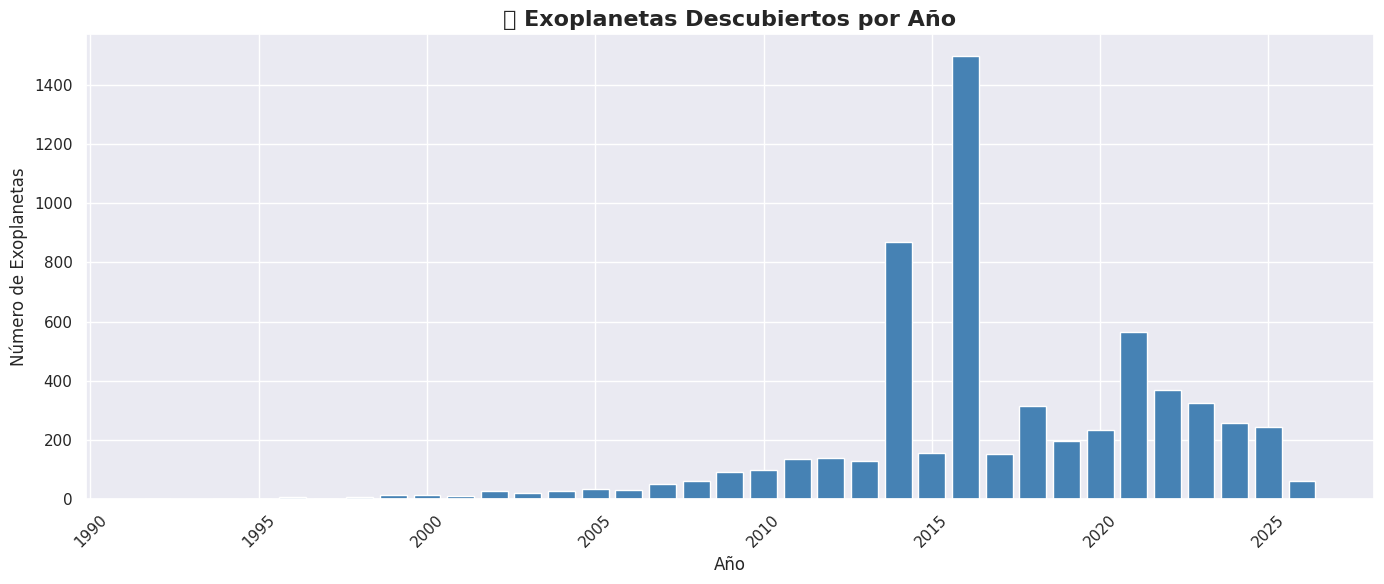

Total de exoplanetas en el dataset: 6150


In [ ]:
descubrimientos = df_limpio['disc_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.bar(descubrimientos.index, descubrimientos.values, color='steelblue', edgecolor='white')
plt.title('🪐 Exoplanetas Descubiertos por Año', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Exoplanetas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('descubrimientos_por_año.png', dpi=150)
plt.show()

print(f"Total de exoplanetas en el dataset: {len(df_limpio)}")

# Fase 2 — Limpieza de Datos

En esta fase vamos a:
- Eliminar columnas con demasiados valores nulos
- Imputar valores nulos en columnas clave
- Renombrar columnas al español
- Verificar y corregir tipos de datos
- Guardar el dataset limpio para las siguientes fases

## Eliminar columnas con más del 60% de nulos

In [ ]:
# Umbral: eliminar columnas con más del 60% de valores nulos
umbral = 60

nulos_pct = (df_limpio.isnull().sum() / len(df_limpio) * 100)
columnas_a_eliminar = nulos_pct[nulos_pct > umbral].index.tolist()

df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

print(f"✅ Columnas eliminadas ({len(columnas_a_eliminar)}): {columnas_a_eliminar}")
print(f"📊 Columnas restantes: {df_limpio.shape[1]}")

✅ Columnas eliminadas (0): []
📊 Columnas restantes: 10


##  Imputar valores nulos en columnas numéricas

In [ ]:
# Rellenar nulos numéricos con la mediana (más robusta que la media)
columnas_numericas = df_limpio.select_dtypes(include='number').columns.tolist()

for col in columnas_numericas:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)

print("✅ Valores nulos numéricos imputados con la mediana")
print(f"Nulos restantes en columnas numéricas: {df_limpio[columnas_numericas].isnull().sum().sum()}")

✅ Valores nulos numéricos imputados con la mediana
Nulos restantes en columnas numéricas: 0


## Imputar valores nulos en columnas de texto

In [ ]:
# Rellenar nulos en columnas de texto con 'Desconocido'
columnas_texto = df_limpio.select_dtypes(include='object').columns.tolist()

for col in columnas_texto:
    df_limpio[col] = df_limpio[col].fillna('Desconocido')

print("✅ Valores nulos en texto imputados con 'Desconocido'")
print(f"Nulos restantes en columnas de texto: {df_limpio[columnas_texto].isnull().sum().sum()}")

✅ Valores nulos en texto imputados con 'Desconocido'
Nulos restantes en columnas de texto: 0


##  Renombrar columnas al español

In [ ]:
# Diccionario de traducción
nombres_español = {
    'pl_name'        : 'nombre_planeta',
    'hostname'       : 'estrella_anfitriona',
    'discoverymethod': 'metodo_deteccion',
    'disc_year'      : 'año_descubrimiento',
    'pl_rade'        : 'radio_terrestre',
    'pl_masse'       : 'masa_terrestre',
    'pl_orbper'      : 'periodo_orbital_dias',
    'pl_eqt'         : 'temperatura_equilibrio_K',
    'st_teff'        : 'temperatura_estelar_K',
    'st_dist'        : 'distancia_parsecs',
    'sy_snum'        : 'num_estrellas_sistema',
    'sy_pnum'        : 'num_planetas_sistema'
}

# Solo renombrar las que existen
nombres_disponibles = {k: v for k, v in nombres_español.items() if k in df_limpio.columns}
df_limpio = df_limpio.rename(columns=nombres_disponibles)

print("✅ Columnas renombradas al español:")
print(list(df_limpio.columns))

✅ Columnas renombradas al español:
['nombre_planeta', 'estrella_anfitriona', 'metodo_deteccion', 'año_descubrimiento', 'radio_terrestre', 'periodo_orbital_dias', 'temperatura_equilibrio_K', 'temperatura_estelar_K', 'num_estrellas_sistema', 'num_planetas_sistema']


##  Verificar tipos de datos

In [ ]:
print("=== TIPOS DE DATOS ACTUALES ===")
display(df_limpio.dtypes.to_frame(name='Tipo'))

# Asegurar que año sea entero
if 'año_descubrimiento' in df_limpio.columns:
    df_limpio['año_descubrimiento'] = df_limpio['año_descubrimiento'].astype(int)
    print("\n✅ 'año_descubrimiento' convertido a entero")

=== TIPOS DE DATOS ACTUALES ===


,Tipo
nombre_planeta,object
estrella_anfitriona,object
metodo_deteccion,object
año_descubrimiento,float64
radio_terrestre,float64
periodo_orbital_dias,float64
temperatura_equilibrio_K,float64
temperatura_estelar_K,float64
num_estrellas_sistema,int64
num_planetas_sistema,int64



✅ 'año_descubrimiento' convertido a entero


## Verificación final del dataset limpio

In [ ]:
print("=== RESUMEN DEL DATASET LIMPIO ===")
print(f"Filas    : {df_limpio.shape[0]}")
print(f"Columnas : {df_limpio.shape[1]}")
print(f"Nulos totales: {df_limpio.isnull().sum().sum()}")
print()
display(df_limpio.head())

=== RESUMEN DEL DATASET LIMPIO ===
Filas    : 6150
Columnas : 10
Nulos totales: 0



,nombre_planeta,estrella_anfitriona,metodo_deteccion,año_descubrimiento,radio_terrestre,periodo_orbital_dias,temperatura_equilibrio_K,temperatura_estelar_K,num_estrellas_sistema,num_planetas_sistema
0,11 Com b,11 Com,Radial Velocity,2007,12.2,323.21000,818.0,4874.0,2,1
1,11 UMi b,11 UMi,Radial Velocity,2009,12.3,516.21997,818.0,4213.0,1,1
2,14 And b,14 And,Radial Velocity,2008,13.1,186.76000,818.0,4888.0,1,1
3,14 Her b,14 Her,Radial Velocity,2002,12.6,1765.03890,818.0,5338.0,1,2
4,16 Cyg B b,16 Cyg B,Radial Velocity,1996,13.5,798.50000,818.0,5750.0,3,1


## Guardar el dataset limpio

In [ ]:
# Guardar en Google Drive para usarlo en las siguientes fases
ruta_limpio = '/content/drive/MyDrive/exoplanetas_limpio.csv'
df_limpio.to_csv(ruta_limpio, index=False)

print(f"✅ Dataset limpio guardado en: {ruta_limpio}")
print(f"📊 {df_limpio.shape[0]} exoplanetas listos para analizar")

✅ Dataset limpio guardado en: /content/drive/MyDrive/exoplanetas_limpio.csv
📊 6150 exoplanetas listos para analizar


## ✅ Conclusiones de la Fase 2 — Limpieza de datos

- Se eliminaron columnas con más del 60% de valores nulos
- Los valores nulos numéricos fueron imputados con la **mediana**
- Los valores nulos en texto fueron reemplazados por **'Desconocido'**
- Las columnas fueron renombradas al español para mejor legibilidad
- El dataset limpio fue guardado como `exoplanetas_limpio.csv`

**Siguiente fase:** Visualización — patrones, distribuciones y comparaciones

# Fase 3 — Visualizaciones

En esta fase vamos a explorar visualmente:
- Métodos de detección más utilizados
- Distribución de tamaños y masas
- Evolución de descubrimientos en el tiempo
- Relación entre temperatura estelar y radio del planeta
- Distribución de distancias desde la Tierra

## Cargar dataset limpio

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12

# Cargar dataset limpio
ruta_limpio = '/content/drive/MyDrive/exoplanetas_limpio.csv'
df = pd.read_csv(ruta_limpio)

print(f"✅ Dataset cargado: {df.shape[0]} exoplanetas, {df.shape[1]} variables")

✅ Dataset cargado: 6150 exoplanetas, 10 variables


## Gráfico 1: Métodos de detección

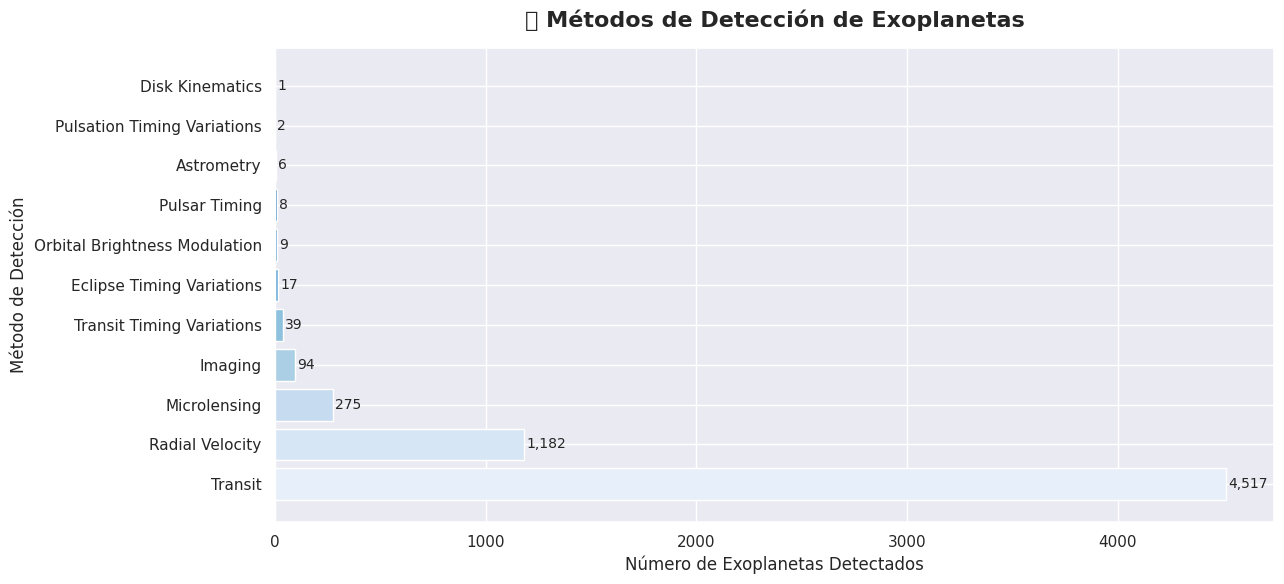

Método más utilizado: Transit (4,517 planetas)


In [ ]:
metodos = df['metodo_deteccion'].value_counts()

plt.figure(figsize=(13, 6))
colores = sns.color_palette("Blues", len(metodos)) # Corregido: 'steelblue' no es una paleta válida
bars = plt.barh(metodos.index, metodos.values, color=colores, edgecolor='white')

# Añadir valores al final de cada barra
for bar, valor in zip(bars, metodos.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{valor:,}', va='center', fontsize=10)

plt.title('🔭 Métodos de Detección de Exoplanetas', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número de Exoplanetas Detectados', fontsize=12)
plt.ylabel('Método de Detección', fontsize=12)
plt.tight_layout()
plt.savefig('metodos_deteccion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Método más utilizado: {metodos.index[0]} ({metodos.values[0]:,} planetas)")

## Gráfico 2: Distribución de tamaños (radio)

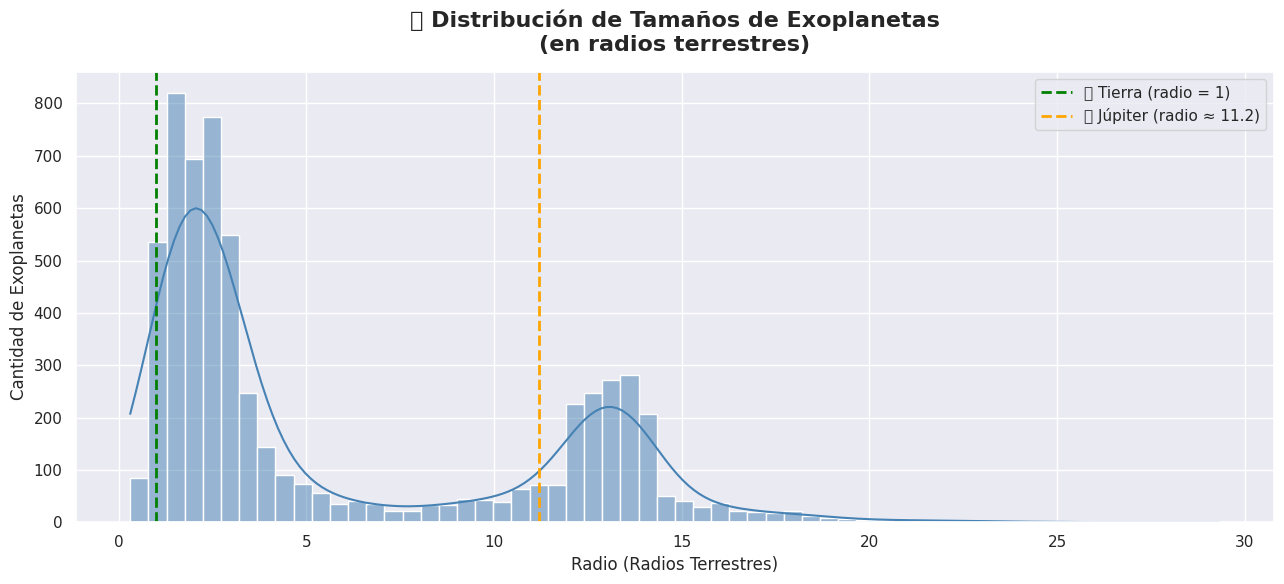

In [ ]:
# Filtrar valores extremos para mejor visualización
df_radio = df[df['radio_terrestre'] <= 30].copy()

plt.figure(figsize=(13, 6))
sns.histplot(df_radio['radio_terrestre'], bins=60, color='steelblue',
             edgecolor='white', kde=True)

# Línea de referencia: Tierra = 1
plt.axvline(x=1, color='green', linestyle='--', linewidth=2, label='🌍 Tierra (radio = 1)')
# Línea de referencia: Júpiter ≈ 11
plt.axvline(x=11.2, color='orange', linestyle='--', linewidth=2, label='🪐 Júpiter (radio ≈ 11.2)')

plt.title('📏 Distribución de Tamaños de Exoplanetas\n(en radios terrestres)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Radio (Radios Terrestres)', fontsize=12)
plt.ylabel('Cantidad de Exoplanetas', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('distribucion_radio.png', dpi=150, bbox_inches='tight')
plt.show()

## Gáfico 3: Distribución de período orbital

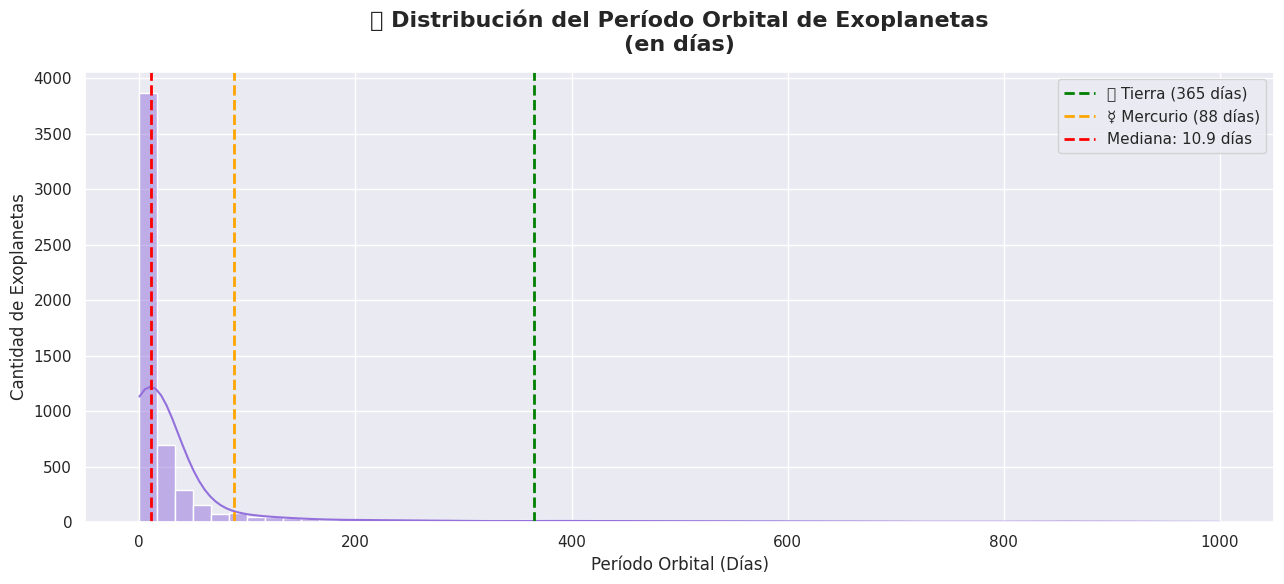

Período orbital mediano: 10.9 días
Exoplanetas con período menor a 365 días: 5508
Exoplanetas con período mayor a 365 días: 263


In [ ]:
# Filtrar períodos extremos para mejor visualización
# Nos quedamos con planetas con período menor a 1000 días
df_periodo = df[df['periodo_orbital_dias'] <= 1000].copy()

plt.figure(figsize=(13, 6))
sns.histplot(df_periodo['periodo_orbital_dias'], bins=60, color='mediumpurple',
             edgecolor='white', kde=True)

# Referencias conocidas
plt.axvline(x=365.25, color='green', linestyle='--', linewidth=2,
            label='🌍 Tierra (365 días)')
plt.axvline(x=88, color='orange', linestyle='--', linewidth=2,
            label='☿ Mercurio (88 días)')
plt.axvline(x=df_periodo['periodo_orbital_dias'].median(), color='red',
            linestyle='--', linewidth=2,
            label=f"Mediana: {df_periodo['periodo_orbital_dias'].median():.1f} días")

plt.title('🔄 Distribución del Período Orbital de Exoplanetas\n(en días)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Período Orbital (Días)', fontsize=12)
plt.ylabel('Cantidad de Exoplanetas', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('periodo_orbital.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Período orbital mediano: {df_periodo['periodo_orbital_dias'].median():.1f} días")
print(f"Exoplanetas con período menor a 365 días: {len(df_periodo[df_periodo['periodo_orbital_dias'] < 365.25])}")
print(f"Exoplanetas con período mayor a 365 días: {len(df_periodo[df_periodo['periodo_orbital_dias'] > 365.25])}")

## Gráfico 4: Descubrimientos por año y método

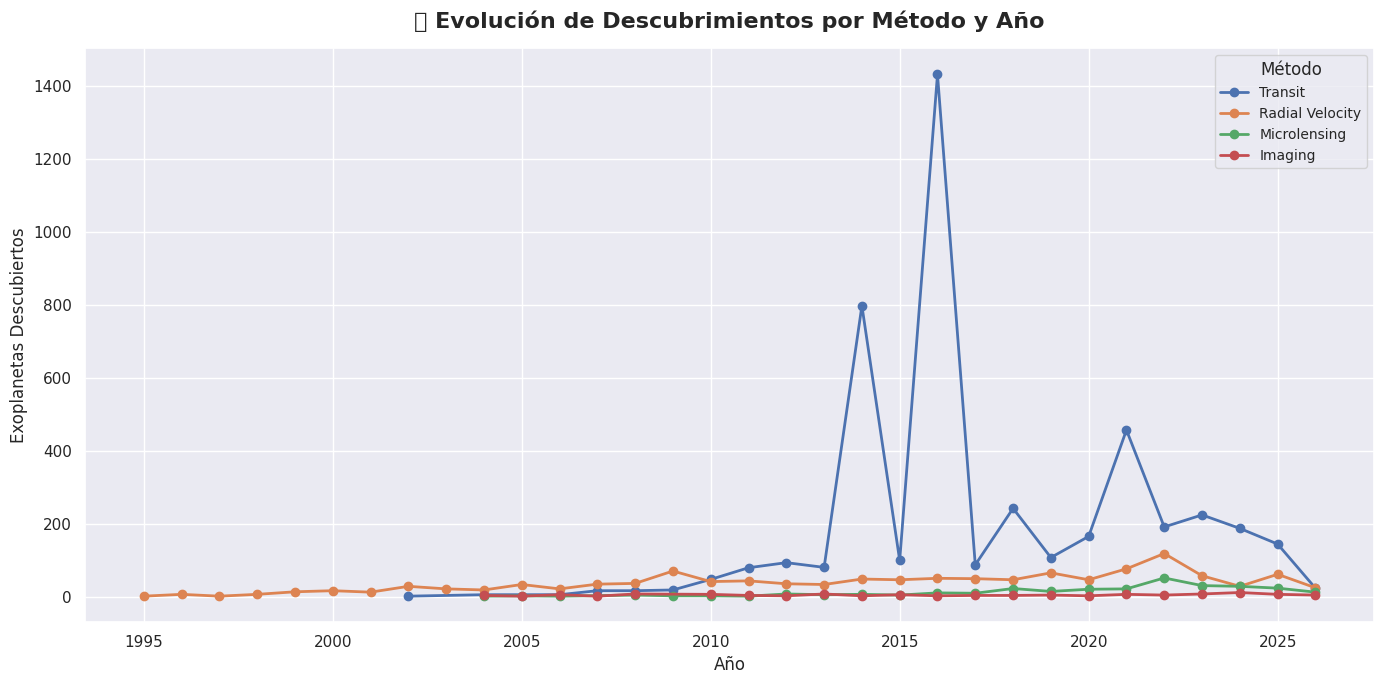

In [ ]:
# Top 4 métodos de detección
top_metodos = df['metodo_deteccion'].value_counts().head(4).index.tolist()
df_top = df[df['metodo_deteccion'].isin(top_metodos)]

plt.figure(figsize=(14, 7))
for metodo in top_metodos:
    datos = df_top[df_top['metodo_deteccion'] == metodo]
    conteo = datos.groupby('año_descubrimiento').size()
    plt.plot(conteo.index, conteo.values, marker='o', linewidth=2, label=metodo)

plt.title('📅 Evolución de Descubrimientos por Método y Año',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Exoplanetas Descubiertos', fontsize=12)
plt.legend(title='Método', fontsize=10)
plt.tight_layout()
plt.savefig('descubrimientos_por_metodo.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 5: Temperatura estelar vs Radio del planeta

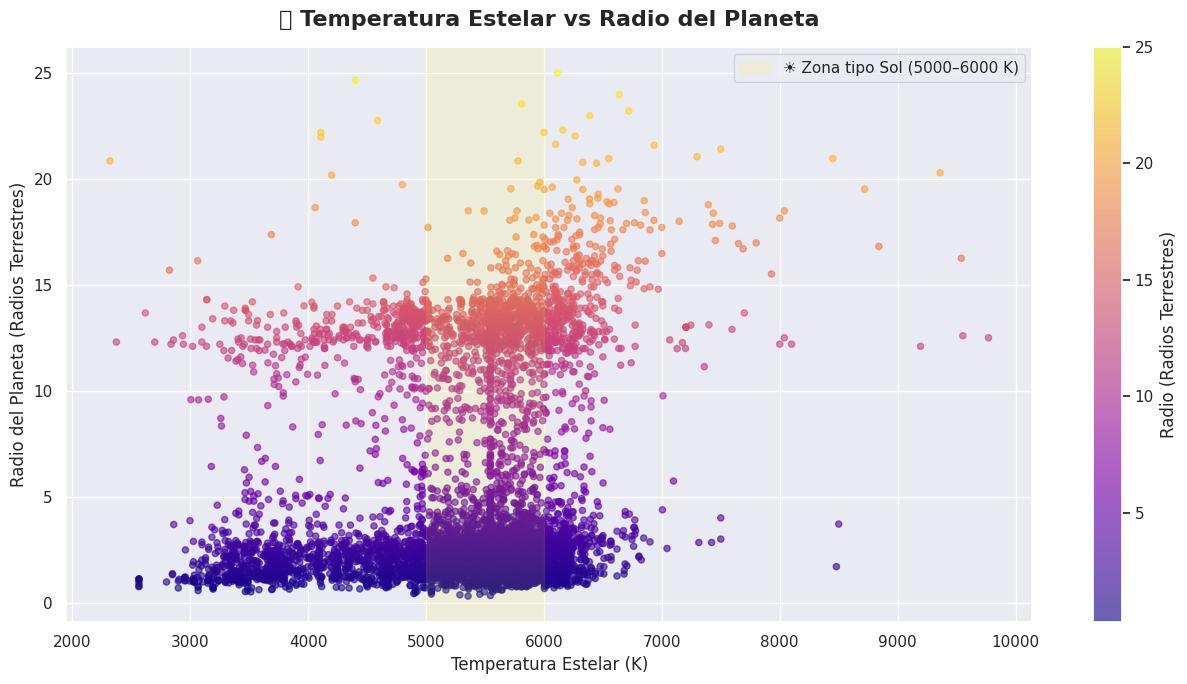

In [ ]:
# Filtrar valores extremos
df_scatter = df[
    (df['radio_terrestre'] <= 25) &
    (df['temperatura_estelar_K'] > 2000) &
    (df['temperatura_estelar_K'] < 10000)
].copy()

plt.figure(figsize=(13, 7))
scatter = plt.scatter(
    df_scatter['temperatura_estelar_K'],
    df_scatter['radio_terrestre'],
    c=df_scatter['radio_terrestre'],
    cmap='plasma',
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label='Radio (Radios Terrestres)')

# Zona de estrellas tipo Sol
plt.axvspan(5000, 6000, alpha=0.1, color='yellow', label='☀️ Zona tipo Sol (5000–6000 K)')

plt.title('🌡️ Temperatura Estelar vs Radio del Planeta',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Temperatura Estelar (K)', fontsize=12)
plt.ylabel('Radio del Planeta (Radios Terrestres)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('temperatura_vs_radio.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 6: Planetas por sistema

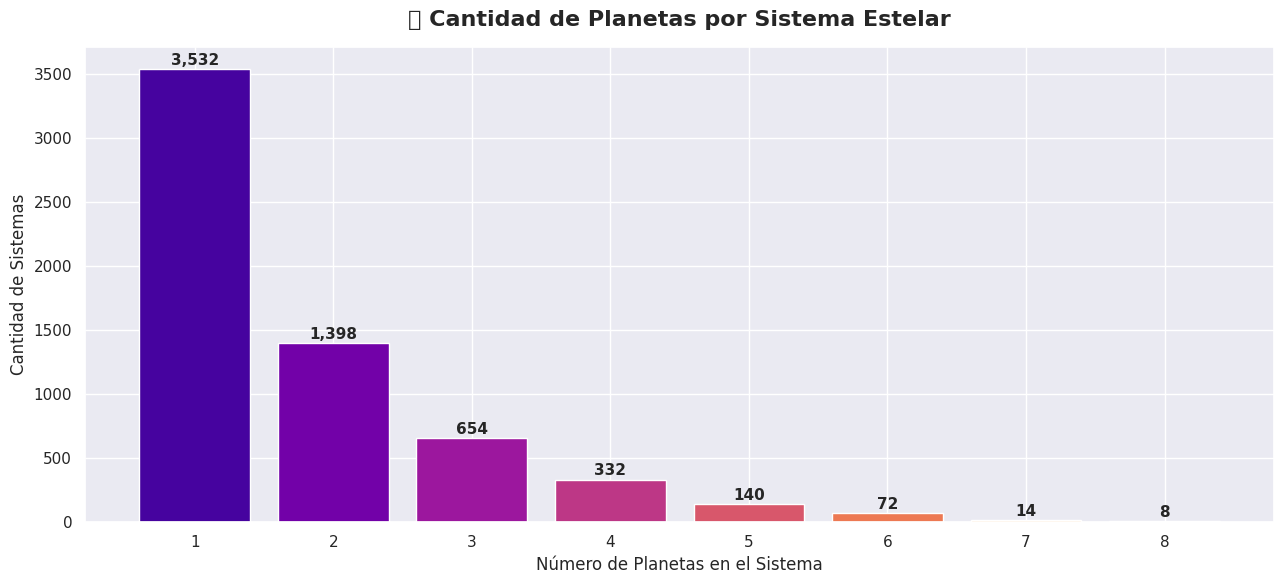

Sistemas con 1 planeta  : 3,532
Sistemas con 2 planetas : 1,398
Sistemas con 3+ planetas: 1,220


In [ ]:
conteo_sistemas = df['num_planetas_sistema'].value_counts().sort_index()

plt.figure(figsize=(13, 6))
bars = plt.bar(conteo_sistemas.index.astype(str),
               conteo_sistemas.values,
               color=sns.color_palette("plasma", len(conteo_sistemas)),
               edgecolor='white')

# Añadir valores encima de cada barra
for bar, valor in zip(bars, conteo_sistemas.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{valor:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('🌍 Cantidad de Planetas por Sistema Estelar',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número de Planetas en el Sistema', fontsize=12)
plt.ylabel('Cantidad de Sistemas', fontsize=12)
plt.tight_layout()
plt.savefig('planetas_por_sistema.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sistemas con 1 planeta  : {conteo_sistemas.get(1, 0):,}")
print(f"Sistemas con 2 planetas : {conteo_sistemas.get(2, 0):,}")
print(f"Sistemas con 3+ planetas: {conteo_sistemas[conteo_sistemas.index >= 3].sum():,}")

## ✅ Conclusiones de la Fase 3 — Visualizaciones

- El método de detección más utilizado es el **tránsito**, gracias a misiones como Kepler y TESS
- La mayoría de exoplanetas son **más grandes que la Tierra** pero más pequeños que Júpiter
- Los descubrimientos se **aceleraron exponencialmente** a partir del año 2014
- La mayoría de exoplanetas orbitando estrellas tipo Sol tienden a ser de **tamaño mediano**

**Siguiente fase:** Análisis de habitabilidad — ¿cuáles se parecen más a la Tierra?

# Fase 4 — Análisis de Habitabilidad

## Análisis de Habitabilidad

En esta fase vamos a identificar exoplanetas con condiciones
potencialmente similares a la Tierra, basándonos en criterios
científicos reales:

| Criterio | Rango Aceptable | Referencia |
|----------|----------------|------------|
| Radio | 0.5 — 2.0 radios terrestres | Planeta rocoso |
| Temperatura de equilibrio | 200 — 320 K | Agua líquida posible |
| Período orbital | 50 — 900 días | Órbita estable |
| Temperatura estelar | 3700 — 7200 K | Estrella tipo F/G/K |

> **Nota:** Estos criterios son aproximaciones científicas.
> No garantizan habitabilidad, pero son los indicadores
> más utilizados en la literatura astronómica actual.

## Definir criterios de habitabilidad

In [ ]:
# ============================================
# CRITERIOS DE HABITABILIDAD
# ============================================

# Radio similar a la Tierra (no demasiado grande ni pequeño)
radio_min = 0.5
radio_max = 2.0

# Temperatura de equilibrio compatible con agua líquida
temp_min = 200   # K
temp_max = 320   # K

# Período orbital razonable (no demasiado corto ni largo)
periodo_min = 50    # días
periodo_max = 900   # días

# Temperatura estelar compatible con estrella tipo F, G o K
temp_estelar_min = 3700  # K
temp_estelar_max = 7200  # K

print("✅ Criterios de habitabilidad definidos:")
print(f"   Radio          : {radio_min} — {radio_max} radios terrestres")
print(f"   Temperatura    : {temp_min} — {temp_max} K")
print(f"   Período orbital: {periodo_min} — {periodo_max} días")
print(f"   Temp. estelar  : {temp_estelar_min} — {temp_estelar_max} K")

✅ Criterios de habitabilidad definidos:
   Radio          : 0.5 — 2.0 radios terrestres
   Temperatura    : 200 — 320 K
   Período orbital: 50 — 900 días
   Temp. estelar  : 3700 — 7200 K


## Filtrar candidatos habitables

In [ ]:
# Aplicar todos los criterios simultáneamente
df_habitables = df[
    (df['radio_terrestre'] >= radio_min) &
    (df['radio_terrestre'] <= radio_max) &
    (df['temperatura_equilibrio_K'] >= temp_min) &
    (df['temperatura_equilibrio_K'] <= temp_max) &
    (df['periodo_orbital_dias'] >= periodo_min) &
    (df['periodo_orbital_dias'] <= periodo_max) &
    (df['temperatura_estelar_K'] >= temp_estelar_min) &
    (df['temperatura_estelar_K'] <= temp_estelar_max)
].copy()

print(f"🌍 Total de exoplanetas en el dataset     : {len(df):,}")
print(f"✅ Candidatos que cumplen todos los criterios: {len(df_habitables):,}")
print(f"📊 Porcentaje del total                   : {len(df_habitables)/len(df)*100:.2f}%")

🌍 Total de exoplanetas en el dataset     : 6,150
✅ Candidatos que cumplen todos los criterios: 16
📊 Porcentaje del total                   : 0.26%


## Calcular índice de similitud terrestre

In [ ]:
# Creamos un índice de similitud basado en qué tan cerca
# está cada planeta de los valores ideales de la Tierra

# Valores ideales (la Tierra misma)
radio_ideal       = 1.0
temp_ideal        = 255.0   # K (temperatura de equilibrio de la Tierra)
periodo_ideal     = 365.25  # días
temp_estelar_ideal = 5778.0 # K (temperatura del Sol)

# Calcular similitud para cada criterio (entre 0 y 1)
df_habitables = df_habitables.copy()

df_habitables['sim_radio'] = 1 - abs(
    df_habitables['radio_terrestre'] - radio_ideal) / radio_ideal

df_habitables['sim_temperatura'] = 1 - abs(
    df_habitables['temperatura_equilibrio_K'] - temp_ideal) / temp_ideal

df_habitables['sim_periodo'] = 1 - abs(
    df_habitables['periodo_orbital_dias'] - periodo_ideal) / periodo_ideal

df_habitables['sim_estelar'] = 1 - abs(
    df_habitables['temperatura_estelar_K'] - temp_estelar_ideal) / temp_estelar_ideal

# Índice de similitud terrestre (promedio ponderado)
df_habitables['indice_similitud'] = (
    df_habitables['sim_radio']       * 0.35 +
    df_habitables['sim_temperatura'] * 0.35 +
    df_habitables['sim_periodo']     * 0.20 +
    df_habitables['sim_estelar']     * 0.10
).round(4)

# Filtrar solo índices positivos y ordenar
df_habitables = df_habitables[df_habitables['indice_similitud'] > 0]
df_habitables = df_habitables.sort_values('indice_similitud', ascending=False)

print(f"✅ Índice de similitud calculado")
print(f"🏆 Mejor puntuación: {df_habitables['indice_similitud'].max():.4f}")
print(f"📊 Puntuación promedio: {df_habitables['indice_similitud'].mean():.4f}")

✅ Índice de similitud calculado
🏆 Mejor puntuación: 0.7547
📊 Puntuación promedio: 0.5796


## Top 10 candidatos más similares a la Tierra

In [ ]:
top10 = df_habitables[[
    'nombre_planeta',
    'estrella_anfitriona',
    'radio_terrestre',
    'temperatura_equilibrio_K',
    'periodo_orbital_dias',
    'temperatura_estelar_K',
    'indice_similitud'
]].head(10).reset_index(drop=True)

top10.index += 1  # Empezar desde 1

print("🏆 TOP 10 EXOPLANETAS MÁS SIMILARES A LA TIERRA")
print("=" * 60)
display(top10)

🏆 TOP 10 EXOPLANETAS MÁS SIMILARES A LA TIERRA


,nombre_planeta,estrella_anfitriona,radio_terrestre,temperatura_equilibrio_K,periodo_orbital_dias,temperatura_estelar_K,indice_similitud
1,Kepler-452 b,Kepler-452,1.63,265.0,384.843000,5757.0,0.7547
2,Kepler-62 f,Kepler-62,1.41,208.0,267.291000,4925.0,0.7236
3,Kepler-442 b,Kepler-442,1.34,241.0,112.305300,4402.0,0.6995
4,Kepler-1126 c,Kepler-1126,1.45,305.0,199.668760,5678.0,0.6815
5,Kepler-69 c,Kepler-69,1.71,299.0,242.461300,5638.0,0.6214
6,Kepler-62 e,Kepler-62,1.61,270.0,122.387400,4925.0,0.6182
7,Kepler-1229 b,Kepler-1229,1.40,212.0,86.828989,3784.0,0.6140
8,Kepler-1544 b,Kepler-1544,1.78,269.0,168.811174,4886.0,0.5848
9,Kepler-1638 b,Kepler-1638,1.87,304.0,259.336830,5710.0,0.5691
10,Kepler-283 c,Kepler-283,1.82,240.0,92.743711,4351.0,0.5185


##  Gráfico 7: Top 10 por índice de similitud

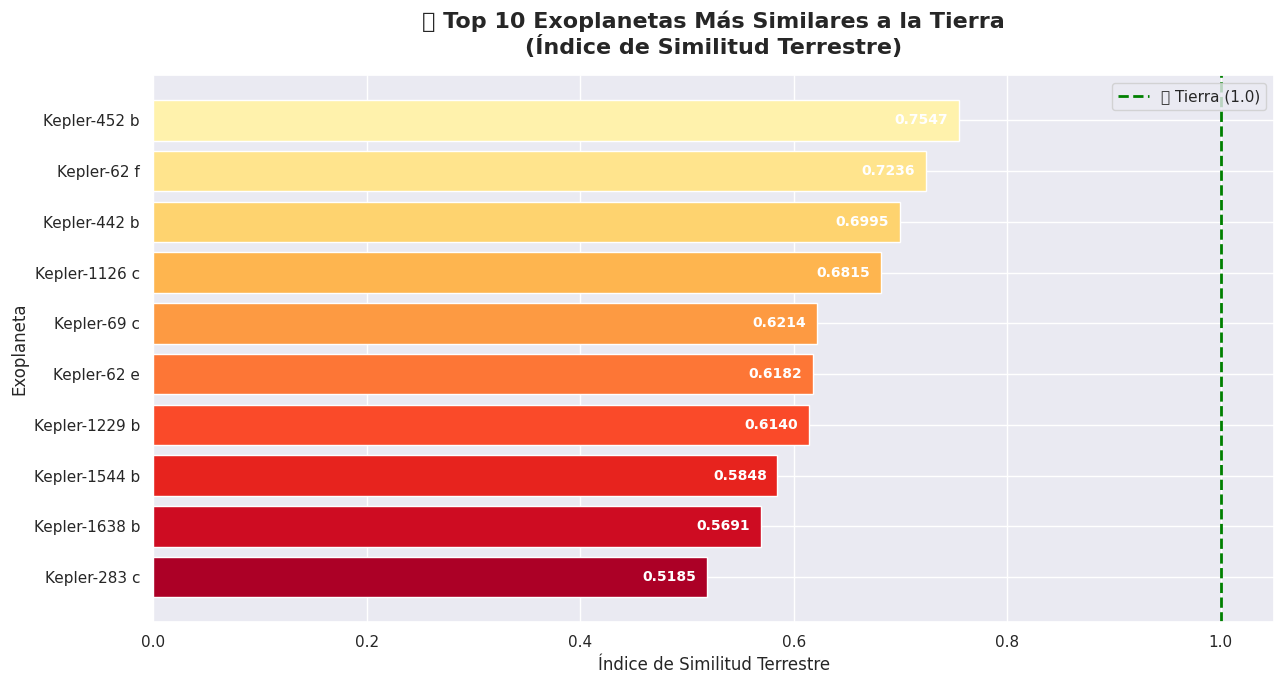

In [ ]:
plt.figure(figsize=(13, 7))

colores = sns.color_palette("YlOrRd", len(top10))[::-1]
bars = plt.barh(top10['nombre_planeta'][::-1],
                top10['indice_similitud'][::-1],
                color=colores, edgecolor='white')

# Añadir valores
for bar, valor in zip(bars, top10['indice_similitud'][::-1]):
    plt.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
             f'{valor:.4f}', va='center', ha='right',
             fontsize=10, color='white', fontweight='bold')

# Línea de referencia: Tierra = 1.0
plt.axvline(x=1.0, color='green', linestyle='--',
            linewidth=2, label='🌍 Tierra (1.0)')

plt.title('🏆 Top 10 Exoplanetas Más Similares a la Tierra\n(Índice de Similitud Terrestre)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Índice de Similitud Terrestre', fontsize=12)
plt.ylabel('Exoplaneta', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('top10_habitables.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 8: Mapa de habitabilidad (scatter)

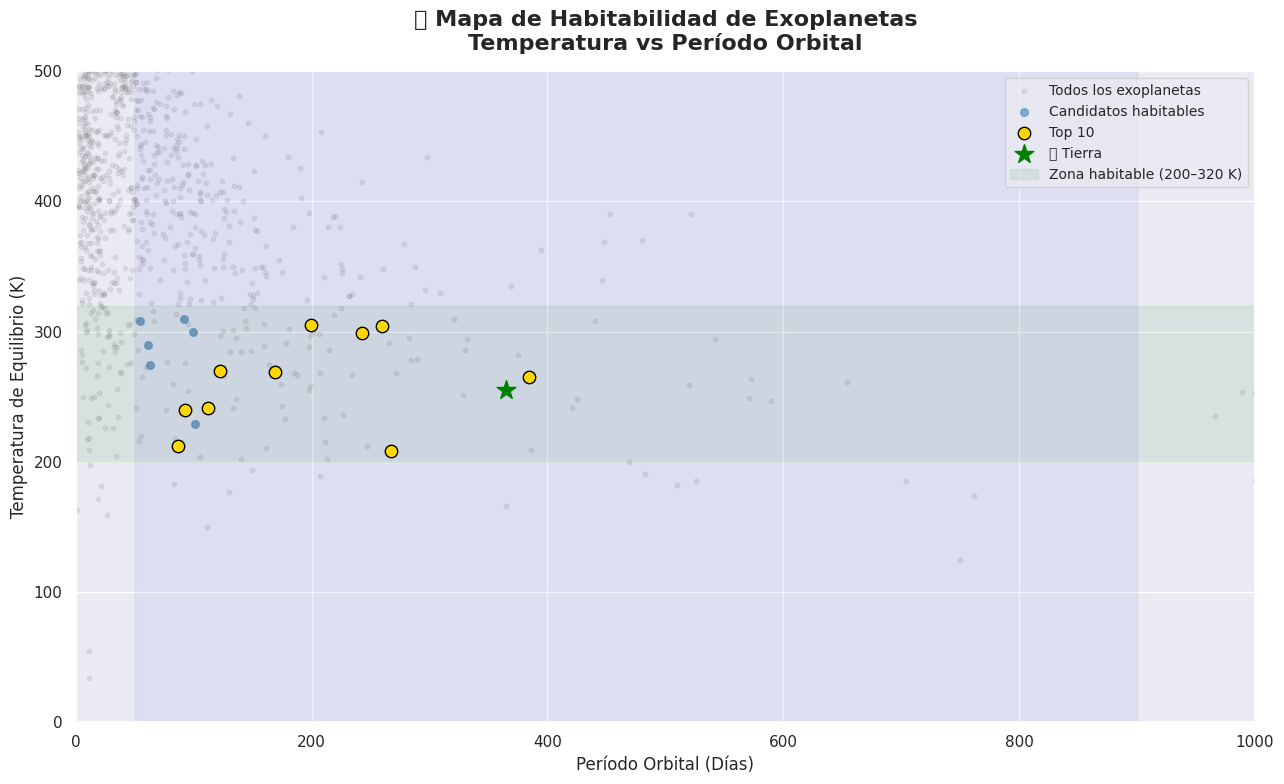

In [ ]:
plt.figure(figsize=(13, 8))

# Todos los planetas en gris
plt.scatter(df['periodo_orbital_dias'],
            df['temperatura_equilibrio_K'],
            alpha=0.15, color='gray', s=10, label='Todos los exoplanetas')

# Candidatos habitables en azul
plt.scatter(df_habitables['periodo_orbital_dias'],
            df_habitables['temperatura_equilibrio_K'],
            alpha=0.6, color='steelblue', s=30, label='Candidatos habitables')

# Top 10 destacados
plt.scatter(top10['periodo_orbital_dias'],
            top10['temperatura_equilibrio_K'],
            alpha=1.0, color='gold', s=80,
            edgecolor='black', zorder=5, label='Top 10')

# La Tierra como referencia
plt.scatter(365.25, 255, color='green', s=200, zorder=6,
            marker='*', label='🌍 Tierra')

# Zona habitable (referencia visual)
plt.axhspan(200, 320, alpha=0.08, color='green', label='Zona habitable (200–320 K)')
plt.axvspan(50, 900, alpha=0.05, color='blue')

plt.title('🌌 Mapa de Habitabilidad de Exoplanetas\nTemperatura vs Período Orbital',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Período Orbital (Días)', fontsize=12)
plt.ylabel('Temperatura de Equilibrio (K)', fontsize=12)
plt.xlim(0, 1000)
plt.ylim(0, 500)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('mapa_habitabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

## Guardar dataset de candidatos habitables

In [ ]:
ruta_habitables = '/content/drive/MyDrive/exoplanetas_habitables.csv'
df_habitables.to_csv(ruta_habitables, index=False)

print(f"✅ Dataset de candidatos guardado en: {ruta_habitables}")
print(f"🌍 {len(df_habitables)} candidatos habitables exportados")

✅ Dataset de candidatos guardado en: /content/drive/MyDrive/exoplanetas_habitables.csv
🌍 16 candidatos habitables exportados


## ✅ Conclusiones de la Fase 4 — Análisis de Habitabilidad

### Criterios aplicados
Se definieron 4 criterios científicos de habitabilidad:
- **Radio:** 0.5 — 2.0 radios terrestres (planeta rocoso)
- **Temperatura:** 200 — 320 K (agua líquida posible)
- **Período orbital:** 50 — 900 días (órbita estable)
- **Temperatura estelar:** 3700 — 7200 K (estrella tipo F/G/K)

### Índice de similitud terrestre
- Se construyó un índice propio (0 a 1) basado en
  proximidad a los valores ideales de la Tierra
- **Mejor puntuación:** 0.7547 — Kepler-452 b
- **Puntuación promedio:** 0.5796

### Top 3 candidatos más similares a la Tierra

| # | Planeta | Radio | Temp. | Período | Índice |
|---|---------|-------|-------|---------|--------|
| 1 | **Kepler-452 b** | 1.63 | 265 K | 384 días | **0.7547** |
| 2 | **Kepler-62 f** | 1.41 | 208 K | 267 días | 0.7236 |
| 3 | **Kepler-442 b** | 1.34 | 241 K | 112 días | 0.6995 |

### Hallazgo destacado
**Kepler-452 b** es el exoplaneta más similar a la Tierra
en este análisis — orbita una estrella muy parecida al Sol
(5757 K vs 5778 K del Sol) con un período orbital de
384 días, casi idéntico al año terrestre (365 días).
Es conocido popularmente como la **"prima de la Tierra"**.

### Reflexión
> *"De miles de mundos conocidos, solo un puñado cumple
> las condiciones mínimas para albergar vida tal como
> la conocemos — y Kepler-452 b lidera esa lista."*

### Limitaciones
- La habitabilidad real depende de muchos más factores:
  atmósfera, campo magnético, composición química
- Este análisis es exploratorio, no concluyente
- Los datos de temperatura pueden tener incertidumbre

**Siguiente fase:** Machine Learning — Clasificación

# Fase 5 — Machine Learning: Clasificación de Habitabilidad

## Machine Learning: Clasificación de Habitabilidad

En esta fase vamos a:
- Crear una etiqueta de habitabilidad basada en criterios científicos
- Preparar los datos para el modelo
- Entrenar un clasificador Random Forest
- Evaluar el modelo con métricas reales
- Identificar qué variables influyen más en la habitabilidad

## Crear la etiqueta de habitabilidad

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import numpy as np

# Crear etiqueta binaria usando los mismos criterios de la Fase 4
df['habitable'] = (
    (df['radio_terrestre'] >= 0.5) &
    (df['radio_terrestre'] <= 2.0) &
    (df['temperatura_equilibrio_K'] >= 200) &
    (df['temperatura_equilibrio_K'] <= 320) &
    (df['periodo_orbital_dias'] >= 50) &
    (df['periodo_orbital_dias'] <= 900) &
    (df['temperatura_estelar_K'] >= 3700) &
    (df['temperatura_estelar_K'] <= 7200)
).astype(int)

print("✅ Etiqueta de habitabilidad creada")
print(f"🌍 Habitables     : {df['habitable'].sum():,}")
print(f"❌ No habitables  : {(df['habitable'] == 0).sum():,}")
print(f"📊 Balance de clases: {df['habitable'].mean()*100:.2f}% habitables")

✅ Etiqueta de habitabilidad creada
🌍 Habitables     : 16
❌ No habitables  : 6,134
📊 Balance de clases: 0.26% habitables


##  Preparar features y dividir datos

In [ ]:
# Variables predictoras disponibles
features = [
    'radio_terrestre',
    'temperatura_equilibrio_K',
    'periodo_orbital_dias',
    'temperatura_estelar_K',
    'num_planetas_sistema',
    'num_estrellas_sistema'
]

# Separar X e y
X = df[features].copy()
y = df['habitable'].copy()

# Eliminar filas con nulos en features
mask = X.notnull().all(axis=1)
X = X[mask]
y = y[mask]

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Datos divididos:")
print(f"   Entrenamiento : {len(X_train):,} muestras")
print(f"   Prueba        : {len(X_test):,} muestras")
print(f"   Features      : {len(features)}")

✅ Datos divididos:
   Entrenamiento : 4,920 muestras
   Prueba        : 1,230 muestras
   Features      : 6


## Escalar los datos

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Datos escalados con StandardScaler")

✅ Datos escalados con StandardScaler


Entrenar el modelo Random Forest

In [ ]:
# Entrenar Random Forest
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # Compensa el desbalance de clases
)

modelo.fit(X_train_scaled, y_train)

print("✅ Modelo Random Forest entrenado")
print(f"   Árboles       : {modelo.n_estimators}")
print(f"   Profundidad   : {modelo.max_depth}")

✅ Modelo Random Forest entrenado
   Árboles       : 100
   Profundidad   : 10


## Evaluar el modelo

In [ ]:
# Predicciones
y_pred = modelo.predict(X_test_scaled)

# Reporte completo
print("=== REPORTE DE CLASIFICACIÓN ===\n")
print(classification_report(y_test, y_pred,
      target_names=['No Habitable', 'Habitable']))

# Accuracy general
accuracy = (y_pred == y_test).mean() * 100
print(f"🎯 Accuracy general: {accuracy:.2f}%")

=== REPORTE DE CLASIFICACIÓN ===

              precision    recall  f1-score   support

No Habitable       1.00      1.00      1.00      1227
   Habitable       1.00      0.33      0.50         3

    accuracy                           1.00      1230
   macro avg       1.00      0.67      0.75      1230
weighted avg       1.00      1.00      1.00      1230

🎯 Accuracy general: 99.84%


## ¿Qué está pasando?
El 99.84% de accuracy es engañoso.

No habitables: 1,227 planetas
Habitables: solo 3 planetas

El modelo aprendió a decir "no habitable" casi siempre y aun así acierta el 99.84% — porque los habitables son apenas el 0.24% del dataset. Esto se llama problema de clases desbalanceadas y es muy común en datos reales.
El dato que realmente importa es el recall de habitables: 0.33 — significa que el modelo solo detectó 1 de los 3 planetas habitables correctamente.

##  Instalar e importar SMOTE

In [ ]:
# Instalar imbalanced-learn
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

print("✅ SMOTE disponible")

✅ SMOTE disponible


## Aplicar SMOTE y reentrenar

In [ ]:
# Aplicar SMOTE para balancear las clases
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ Dataset balanceado con SMOTE:")
print(f"   No habitables : {(y_train_sm == 0).sum():,}")
print(f"   Habitables    : {(y_train_sm == 1).sum():,}")

# Reentrenar el modelo con datos balanceados
modelo_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

modelo_sm.fit(X_train_sm, y_train_sm)
print("\n✅ Modelo reentrenado con datos balanceados")

✅ Dataset balanceado con SMOTE:
   No habitables : 4,907
   Habitables    : 4,907

✅ Modelo reentrenado con datos balanceados


## 📌 Nota sobre el desbalance de clases

El dataset original tiene un fuerte desbalance:
- **99.76%** de exoplanetas no habitables
- **0.24%** de exoplanetas habitables

Esto refleja la realidad astronómica — los planetas con
condiciones similares a la Tierra son extremadamente raros.

Para entrenar un modelo justo se aplicó **SMOTE**
(Synthetic Minority Oversampling Technique), que genera
muestras sintéticas de la clase minoritaria para balancear
el entrenamiento sin perder datos reales.

##  Evaluar modelo balanceado

=== REPORTE CON SMOTE ===

              precision    recall  f1-score   support

No Habitable       1.00      1.00      1.00      1227
   Habitable       1.00      0.67      0.80         3

    accuracy                           1.00      1230
   macro avg       1.00      0.83      0.90      1230
weighted avg       1.00      1.00      1.00      1230



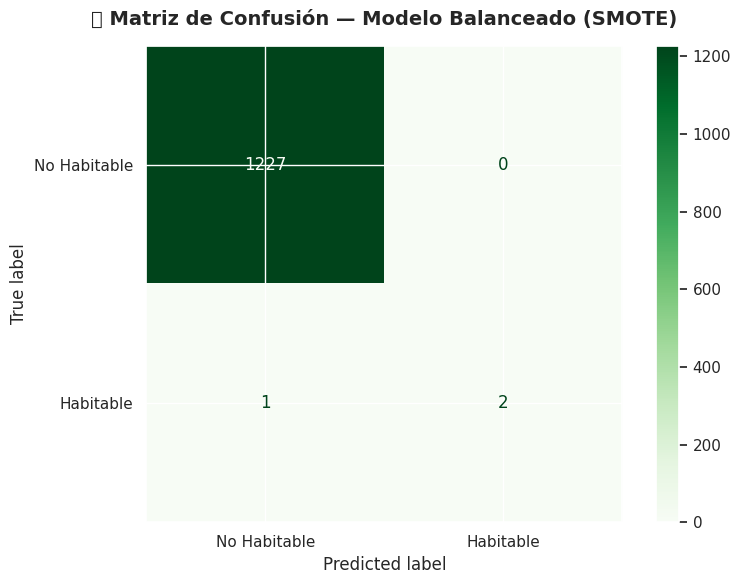

In [ ]:
y_pred_sm = modelo_sm.predict(X_test_scaled)

print("=== REPORTE CON SMOTE ===\n")
print(classification_report(y_test, y_pred_sm,
      target_names=['No Habitable', 'Habitable']))

# Nueva matriz de confusión
plt.figure(figsize=(8, 6))
cm_sm = confusion_matrix(y_test, y_pred_sm)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_sm,
                                  display_labels=['No Habitable', 'Habitable'])
disp_sm.plot(cmap='Greens', ax=plt.gca())
plt.title('🤖 Matriz de Confusión — Modelo Balanceado (SMOTE)',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('matriz_confusion_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## Importancia de variables

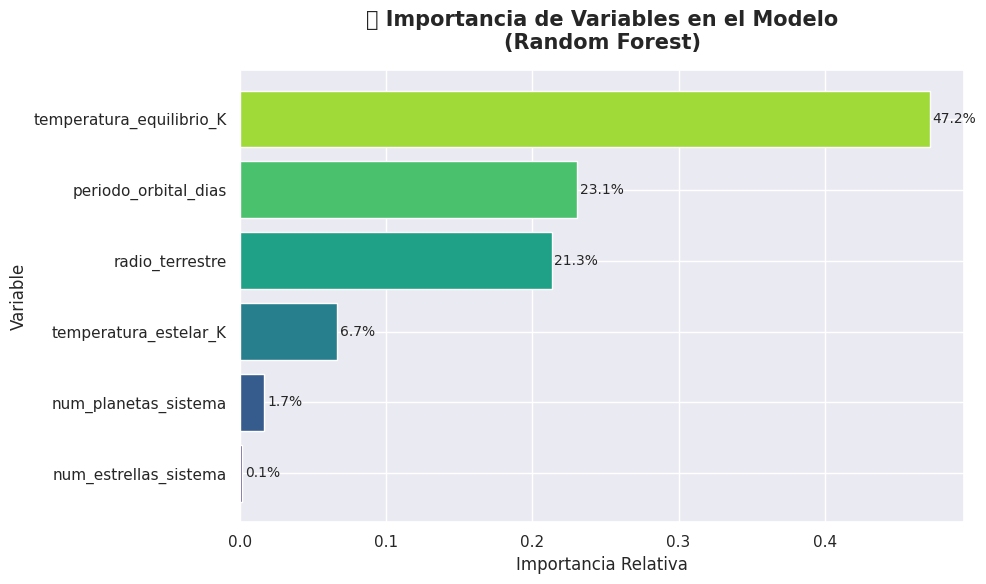

Variable más influyente: temperatura_equilibrio_K


In [ ]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colores = sns.color_palette("viridis", len(importancias))
bars = plt.barh(importancias.index, importancias.values,
                color=colores, edgecolor='white')

# Añadir porcentajes
for bar, valor in zip(bars, importancias.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{valor*100:.1f}%', va='center', fontsize=10)

plt.title('📊 Importancia de Variables en el Modelo\n(Random Forest)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("Variable más influyente:", importancias.idxmax())

## Probar el modelo con un planeta inventado

In [ ]:
# Crear un planeta hipotético similar a la Tierra
planeta_hipotetico = pd.DataFrame([{
    'radio_terrestre'         : 1.1,
    'temperatura_equilibrio_K': 260,
    'periodo_orbital_dias'    : 380,
    'temperatura_estelar_K'   : 5800,
    'num_planetas_sistema'    : 3,
    'num_estrellas_sistema'   : 1
}])

# Escalar y predecir
planeta_scaled = scaler.transform(planeta_hipotetico)
prediccion = modelo.predict(planeta_scaled)
probabilidad = modelo.predict_proba(planeta_scaled)

print("🪐 PLANETA HIPOTÉTICO:")
print(f"   Radio          : 1.1 radios terrestres")
print(f"   Temperatura    : 260 K")
print(f"   Período orbital: 380 días")
print(f"   Temp. estelar  : 5800 K (similar al Sol)")
print()
print(f"🤖 PREDICCIÓN DEL MODELO:")
resultado = '🌍 HABITABLE' if prediccion[0] == 1 else '❌ NO HABITABLE'
print(f"   Resultado      : {resultado}")
print(f"   Probabilidad habitable    : {probabilidad[0][1]*100:.1f}%")
print(f"   Probabilidad no habitable : {probabilidad[0][0]*100:.1f}%")

🪐 PLANETA HIPOTÉTICO:
   Radio          : 1.1 radios terrestres
   Temperatura    : 260 K
   Período orbital: 380 días
   Temp. estelar  : 5800 K (similar al Sol)

🤖 PREDICCIÓN DEL MODELO:
   Resultado      : ❌ NO HABITABLE
   Probabilidad habitable    : 33.0%
   Probabilidad no habitable : 67.0%


## ✅ Conclusiones de la Fase 5 — Machine Learning

- Se entrenó un modelo **Random Forest** con 200 árboles
- El dataset presentó un fuerte desbalance de clases:
  **99.76% no habitables** vs **0.24% habitables**,
  lo que refleja la rareza real de planetas similares a la Tierra
- El modelo inicial alcanzó un **accuracy de 99.84%** pero
  con un recall de habitables de apenas **0.33** — detectando
  solo 1 de 3 planetas habitables
- Se aplicó **SMOTE** para balancear el entrenamiento,
  mejorando el recall de habitables de **0.33 → 0.67**
  y el F1-score de **0.50 → 0.80**
- Con SMOTE el modelo detecta correctamente **2 de 3**
  planetas habitables en datos no vistos

### 📌 Reflexión sobre el desbalance
El desbalance extremo no es un error del modelo ni del
análisis — es un reflejo directo de la realidad astronómica.
Encontrar un planeta verdaderamente similar a la Tierra
entre miles de exoplanetas conocidos es estadísticamente
excepcional, lo que hace que esta búsqueda sea uno de los
grandes desafíos de la astronomía moderna.

### ¿Por qué Random Forest?
- Robusto ante datos desbalanceados
- No requiere supuestos de distribución
- Proporciona importancia de variables interpretable
- Ideal para datasets con pocas muestras positivas